<a target="_blank" href="https://colab.research.google.com/github/binsue0/.github/blob/main/ML_day2/2_3_SVM_10min.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Support Vector Machine

### Reference
https://datascienceschool.net/ , Hands-on Machine Learning

**"경계선을 어디에 그을까?"** 를 가장 안전하게 정하는 방법이 SVM입니다.

- 마진(margin)과 서포트 벡터
- C: 얼마나 봐줄 것인가 (soft margin)
- 커널 트릭: 직선으로 못 나누는 문제 풀기
- 실습: 유방암 데이터 분류

## 1. 기본 SVM

두 클래스를 나누는 직선은 무수히 많습니다. SVM은 그중 **양쪽 데이터에서 가장 멀리 떨어진** 직선을 고릅니다.
경계선과 가장 가까운 점들까지의 거리를 **마진(margin)** 이라 하고, 그 점들을 **서포트 벡터(support vector)** 라 부릅니다.
경계선은 **오직 이 서포트 벡터들만으로** 결정됩니다.

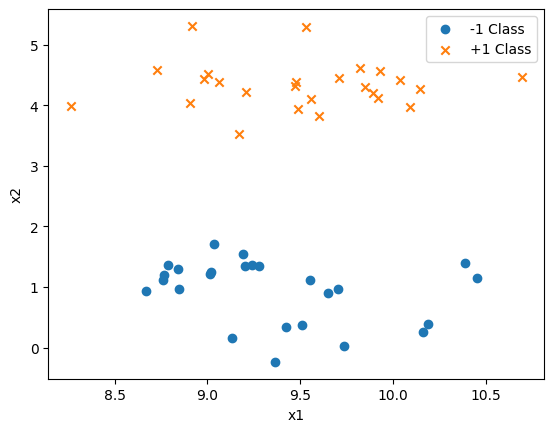

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs


X, y = make_blobs(n_samples=50, centers=2, cluster_std=0.5, random_state=4)
y = 2 * y - 1     # 레이블을 -1과 +1로

plt.scatter(X[y == -1, 0], X[y == -1, 1], marker='o', label='-1 Class')
plt.scatter(X[y == +1, 0], X[y == +1, 1], marker='x', label='+1 Class')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

In [2]:
# (결정 경계=실선, 마진=점선, 서포트 벡터=초록 원)
def plot_svm(model, X, y, ax=None, title=''):
    ax = ax or plt.gca()
    x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300)
    x2 = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
    XX, YY = np.meshgrid(x1, x2)
    Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=40, edgecolors='k', linewidths=0.5)
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=250, facecolors='none', edgecolors='g', linewidths=1.5)
    ax.set_title(title)

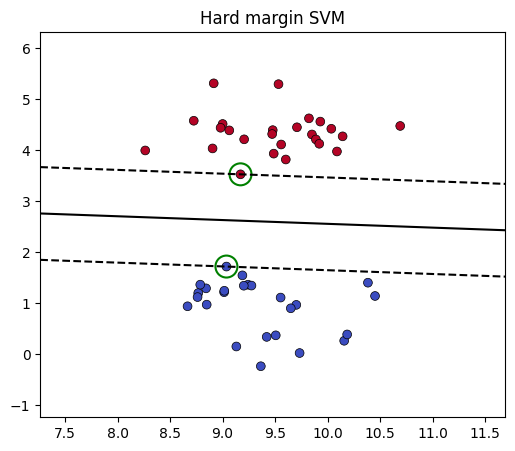

서포트 벡터 개수: 2


In [3]:
# C를 아주 크게 주면 오차를 전혀 허용하지 않는 hard margin이 됩니다.
model = SVC(kernel='linear', C=1e10).fit(X, y)

plt.figure(figsize=(6, 5))
plot_svm(model, X, y, title='Hard margin SVM')
plt.show()

print('서포트 벡터 개수:', len(model.support_vectors_))

In [4]:
# 새로운 점은 어느 쪽일까? decision_function의 부호로 판정합니다.
x_new = [[10, 2]]

print('점수:', model.decision_function(x_new))
print('예측:', model.predict(x_new))

점수: [-0.61101582]
예측: [-1]


## 2. C(soft margin)

현실 데이터는 깔끔하게 안 나뉩니다. 그래서 약간의 오차($\xi_i$)를 허용하고 벌점을 줍니다.

$$\min_{\mathbf{w}, b, \boldsymbol\xi} \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^{n}\xi_i$$

- **C가 크면**: 오차에 벌점이 크다 → 마진이 좁아지고 경계가 복잡해짐 → **과적합** 위험
- **C가 작으면**: 오차를 너그럽게 봐줌 → 마진이 넓어지고 단순해짐 → **과소적합** 위험

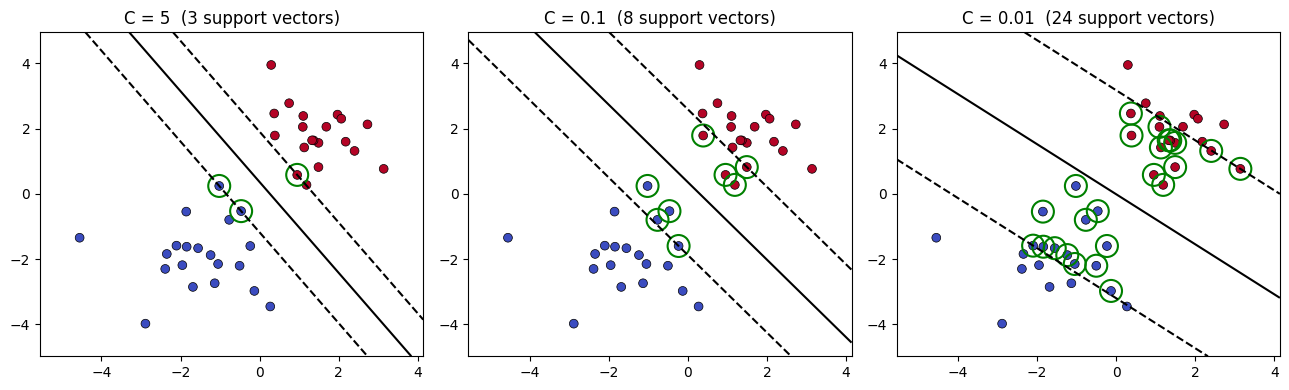

In [5]:
np.random.seed(0)
X2 = np.r_[np.random.randn(20, 2) - [2, 2], np.random.randn(20, 2) + [2, 2]]
y2 = np.array([-1] * 20 + [1] * 20)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, c in zip(axes, [5, 0.1, 0.01]):
    clf = SVC(kernel='linear', C=c).fit(X2, y2)
    plot_svm(clf, X2, y2, ax=ax, title=f'C = {c}  ({len(clf.support_vectors_)} support vectors)')

plt.tight_layout()
plt.show()

C가 작아질수록 마진(점선 사이 폭)이 **넓어지고** 서포트 벡터도 많아집니다.
많은 점이 경계 결정에 참여하니 그만큼 노이즈에 덜 흔들립니다.

## 3. 커널 트릭

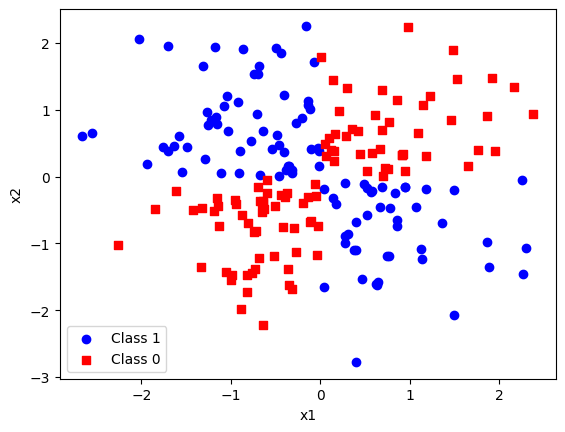

In [6]:
# 대표적인 선형 분리 불가능 문제: XOR
np.random.seed(0)
X_xor = np.random.randn(200, 2)
y_xor = np.where(np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0), 1, 0)

plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], c='b', marker='o', label='Class 1')
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], c='r', marker='s', label='Class 0')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

In [7]:
# 예측 영역을 색칠하는 함수 (다중 클래스에서도 됩니다)
def plot_regions(model, X, y, ax=None, title=''):
    ax = ax or plt.gca()
    x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300)
    x2 = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
    XX, YY = np.meshgrid(x1, x2)
    Z = model.predict(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)

    ax.contourf(XX, YY, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=30, edgecolors='k', linewidths=0.3)
    ax.set_title(title)

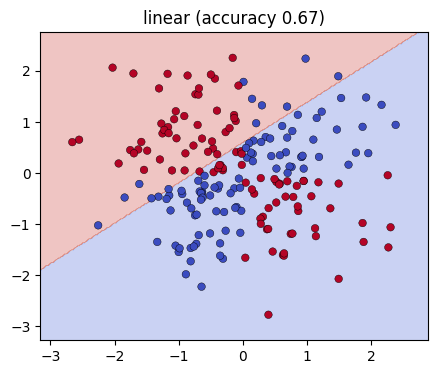

In [8]:
# 선형 SVM으로는 절반밖에 못 맞힙니다.
svc_lin = SVC(kernel='linear').fit(X_xor, y_xor)

plt.figure(figsize=(5, 4))
plot_regions(svc_lin, X_xor, y_xor, title=f'linear (accuracy {svc_lin.score(X_xor, y_xor):.2f})')
plt.show()

### 아이디어: 차원을 올리면 직선으로 나뉜다

$(x_1, x_2)$를 $(x_1^2,\ \sqrt{2}x_1x_2,\ x_2^2)$로 바꿔서 보면 XOR도 직선으로 나뉩니다.

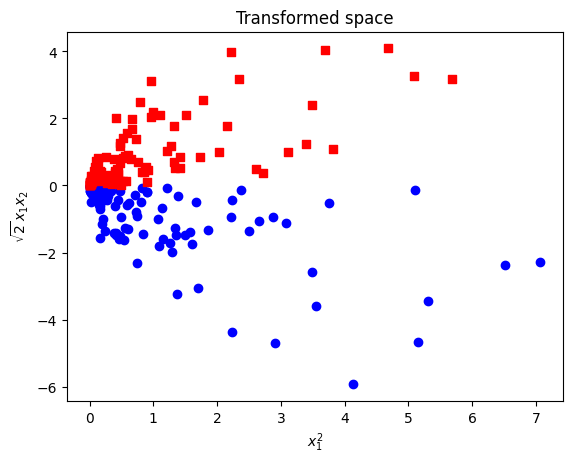

In [9]:
# 특성을 손으로 바꿔봅니다.
Z_xor = np.vstack([X_xor[:, 0] ** 2,
                   np.sqrt(2) * X_xor[:, 0] * X_xor[:, 1],
                   X_xor[:, 1] ** 2]).T

plt.scatter(Z_xor[y_xor == 1, 0], Z_xor[y_xor == 1, 1], c='b', marker='o')
plt.scatter(Z_xor[y_xor == 0, 0], Z_xor[y_xor == 0, 1], c='r', marker='s')
plt.xlabel(r'$x_1^2$')
plt.ylabel(r'$\sqrt{2}\,x_1 x_2$')
plt.title('Transformed space')
plt.show()

두 번째 축을 기준으로 위아래로 깔끔하게 나뉘죠?

그런데 특성을 실제로 만들어 고차원에서 계산하면 비쌉니다.
**커널 트릭**은 고차원으로 옮기지 않고 **내적만 대신 계산해서** 같은 효과를 냅니다.

$$K(\mathbf{x}_1, \mathbf{x}_2) = \exp(-\gamma\|\mathbf{x}_1 - \mathbf{x}_2\|^2) \;\;\text{(RBF)}$$

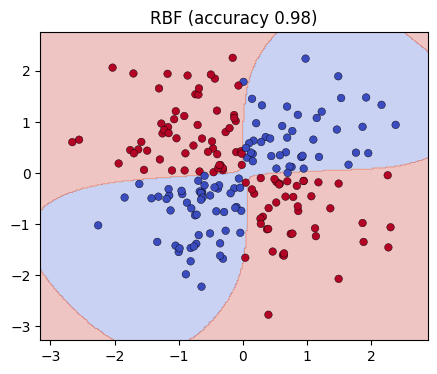

In [10]:
# kernel='rbf' 한 줄이면 끝납니다.
svc_rbf = SVC(kernel='rbf').fit(X_xor, y_xor)

plt.figure(figsize=(5, 4))
plot_regions(svc_rbf, X_xor, y_xor, title=f'RBF (accuracy {svc_rbf.score(X_xor, y_xor):.2f})')
plt.show()

### 커널 종류

$$\text{RBF: } \exp(-\gamma\|\mathbf{x}_1-\mathbf{x}_2\|^2) \qquad
\text{Poly: } (\gamma\,\mathbf{x}_1^{\top}\mathbf{x}_2 + r)^d \qquad
\text{Sigmoid: } \tanh(\gamma\,\mathbf{x}_1^{\top}\mathbf{x}_2 + r)$$

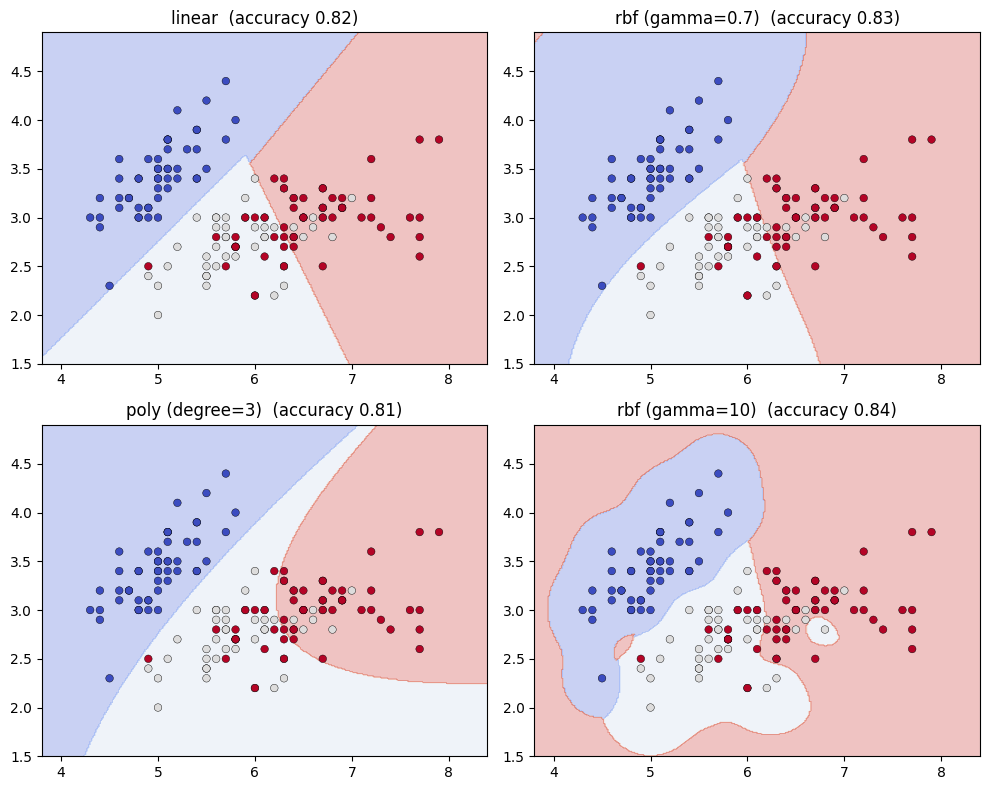

In [11]:
# 붓꽃 데이터(특성 2개)로 커널별 결정 경계를 비교합니다.
from sklearn.datasets import load_iris

iris = load_iris()
X_iris, y_iris = iris.data[:, :2], iris.target

models = [
    ('linear', SVC(kernel='linear', C=1)),
    ('rbf (gamma=0.7)', SVC(kernel='rbf', gamma=0.7, C=1)),
    ('poly (degree=3)', SVC(kernel='poly', degree=3, gamma='auto', C=1)),
    ('rbf (gamma=10)', SVC(kernel='rbf', gamma=10, C=1)),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (name, m) in zip(axes.ravel(), models):
    m.fit(X_iris, y_iris)
    plot_regions(m, X_iris, y_iris, ax=ax, title=f'{name}  (accuracy {m.score(X_iris, y_iris):.2f})')

plt.tight_layout()
plt.show()

`gamma`는 **한 점의 영향 범위**입니다. 크면 각 점 주변만 좁게 보므로 경계가 울퉁불퉁해지고 과적합하기 쉽습니다.
(오른쪽 아래 그림)

## 4. 실습: 유방암 데이터 분류

In [12]:
from sklearn import datasets
from sklearn.model_selection import train_test_split

cancer = datasets.load_breast_cancer()

print(cancer.data.shape)          # 569개 샘플, 30개 특성
print(cancer.target_names)        # 0 = malignant(악성), 1 = benign(양성)

(569, 30)
['malignant' 'benign']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.4, random_state=109)

X_train.shape, X_test.shape

((341, 30), (228, 30))

SVM은 **거리**로 계산하기 때문에 특성의 단위가 다르면 큰 값을 가진 특성에 끌려갑니다.
표준화를 같이 묶어 파이프라인으로 만듭니다.

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1, gamma='scale'))
clf.fit(X_train, y_train)

pred = clf.predict(X_test)

In [15]:
print('accuracy :', metrics.accuracy_score(y_test, pred))
print('precision:', metrics.precision_score(y_test, pred))
print('recall   :', metrics.recall_score(y_test, pred))
print()
print(metrics.classification_report(y_test, pred, target_names=cancer.target_names))

accuracy : 0.9692982456140351
precision: 0.958041958041958
recall   : 0.9927536231884058

              precision    recall  f1-score   support

   malignant       0.99      0.93      0.96        90
      benign       0.96      0.99      0.98       138

    accuracy                           0.97       228
   macro avg       0.97      0.96      0.97       228
weighted avg       0.97      0.97      0.97       228



In [16]:
# 표준화를 빼면 어떻게 될까요?
raw_clf = SVC(kernel='rbf', C=1, gamma='scale').fit(X_train, y_train)

print('표준화 O:', clf.score(X_test, y_test))
print('표준화 X:', raw_clf.score(X_test, y_test))

표준화 O: 0.9692982456140351
표준화 X: 0.8903508771929824


### To-do

`kernel`, `C`, `gamma`를 바꿔가며 점수가 어떻게 변하는지 관찰해 보세요.

```python
clf = make_pipeline(StandardScaler(), SVC(kernel=???, C=???, gamma=???))
```

In [17]:
# 예시: C를 바꿔가며 비교해 보기
for c in [0.01, 0.1, 1, 10, 100]:
    m = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=c)).fit(X_train, y_train)
    print(f'C = {c:6}  ->  test 정확도 {m.score(X_test, y_test):.4f}')

C =   0.01  ->  test 정확도 0.6053
C =    0.1  ->  test 정확도 0.9342
C =      1  ->  test 정확도 0.9693
C =     10  ->  test 정확도 0.9737
C =    100  ->  test 정확도 0.9649


## 정리

| 개념 | 뜻 |
|---|---|
| 마진 | 경계선과 가장 가까운 데이터 사이의 거리. SVM은 이걸 최대로 만든다 |
| 서포트 벡터 | 경계선을 결정하는 소수의 점들 |
| C | 오차를 얼마나 봐줄지. 크면 과적합, 작으면 과소적합 |
| 커널 | 고차원으로 옮기지 않고 비선형 경계를 만드는 방법 (rbf, poly, sigmoid) |
| gamma | RBF에서 한 점의 영향 범위. 크면 경계가 복잡해짐 |

기억할 것
1. SVM은 **경계 근처의 점들만** 보고 결정한다
2. 직선으로 안 되면 **커널**을 바꾼다
3. 쓰기 전에 **반드시 표준화**한다
